<a href="https://colab.research.google.com/github/taka-yu-ki/AI-research/blob/main/AI%E3%83%BB%E3%83%A1%E3%83%87%E3%82%A3%E3%82%A2%E4%BF%A1%E5%8F%B7%E5%87%A6%E7%90%86%E7%A0%94%E7%A9%B6%E5%AE%A4_%E7%A0%94%E7%A9%B6%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import csv
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt

def main():

    # 不要な括弧や空白を削除する関数
    def clean_string(column):
        if isinstance(column, str):
            return column.replace(")", "").replace("]", "").strip()
        return column

    # 'Ã'をNaNに変換する関数
    def replace_unsafe_characters(column):
        if isinstance(column, str) and "Ã" in column:
            return np.nan
        return column

    # 岩手県釜石港の鮭の漁獲量/隻数のデータパス
    salmon_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(鮭)_結合データ.csv"
    # 岩手県釜石港の鮭の餌（イワシ）の漁獲量/隻数のデータパス
    salmon_feed_sardine_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(イワシ)_結合データ.csv"
    # 岩手県釜石港の鮭の餌（イカ）の漁獲量/隻数のデータパス
    salmon_feed_squid_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(イカ)_結合データ.csv"
    # # 岩手県釜石港の平均水温データパス
    average_water_temperature_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水温_結合データ_線形補完.csv"
    # 岩手県釜石港の平均海面気圧データパス
    mean_sea_level_pressure_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_大船渡_海面平均気圧_結合データ.csv"


    # データの読み込み
    salmon_data_df = pd.read_csv(salmon_data_file)
    salmon_feed_sardine_data_df = pd.read_csv(salmon_feed_sardine_data_file)
    salmon_feed_squid_data_df = pd.read_csv(salmon_feed_squid_data_file)
    average_water_temperature_data_df = pd.read_csv(average_water_temperature_data_file)
    mean_sea_level_pressure_data_df = pd.read_csv(mean_sea_level_pressure_data_file)

    # 海面平均気圧データの修正
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].apply(clean_string)
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].apply(replace_unsafe_characters)

    # 欠損値を線形補完
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].astype(float)
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].interpolate()

    # 学習用データと検証データを設定
    y = salmon_data_df['水揚量_per_隻数']

    merge_data = pd.merge(salmon_feed_sardine_data_df, salmon_feed_squid_data_df, on='日付', suffixes=['_イワシ', '_イカ'])
    merge_data = pd.merge(merge_data, mean_sea_level_pressure_data_df, on='日付')
    merge_data = pd.merge(merge_data, average_water_temperature_data_df, on='日付')

    # 説明変数
    X = merge_data[['水揚量_per_隻数_イワシ', '水揚量_per_隻数_イカ', '海面平均気圧(hPa)', '平均水温(℃)']]
    train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=0)

    # 線形単回帰
    model1 = LinearRegression()
    model1.fit(train_X, train_y)
    print("線形単回帰:", model1.score(test_X, test_y))

    # リッジ回帰
    model2 = Ridge()
    model2.fit(train_X, train_y)
    print("リッジ回帰:", model2.score(test_X, test_y))

    # ラッソ回帰
    model3 = Lasso()
    model3.fit(train_X, train_y)
    print("ラッソ回帰:", model3.score(test_X, test_y))

    # 決定木回帰
    model4 = DecisionTreeRegressor()
    model4.fit(train_X, train_y)
    print("決定木回帰:", model4.score(test_X, test_y))

    # ランダムフォレスト回帰
    model5 = RandomForestRegressor()
    model5.fit(train_X, train_y)
    print("ランダムフォレスト回帰:", model5.score(test_X, test_y))

    # XGBoost回帰
    model6 = XGBRegressor()
    model6.fit(train_X, train_y)
    print("XGBoost回帰:", model6.score(test_X, test_y))

if __name__ == "__main__":
    main()

線形単回帰: 0.17832923970479264
リッジ回帰: 0.1782833592877826
ラッソ回帰: 0.17813549292003483
決定木回帰: 0.48924960926240046
ランダムフォレスト回帰: 0.4418497181273968
XGBoost回帰: 0.5748838626182621


In [ ]:
import pandas as pd
import csv
import numpy as np

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

import matplotlib.pyplot as plt

def main():

    # 不要な括弧や空白を削除する関数
    def clean_string(column):
        if isinstance(column, str):
            return column.replace(")", "").replace("]", "").strip()
        return column

    # 'Ã'をNaNに変換する関数
    def replace_unsafe_characters(column):
        if isinstance(column, str) and "Ã" in column:
            return np.nan
        return column

    # 岩手県釜石港の鮭の漁獲量/隻数のデータパス
    salmon_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(鮭)_結合データ.csv"
    # 岩手県釜石港の鮭の餌（イワシ）の漁獲量/隻数のデータパス
    salmon_feed_sardine_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(イワシ)_結合データ.csv"
    # 岩手県釜石港の鮭の餌（イカ）の漁獲量/隻数のデータパス
    salmon_feed_squid_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(イカ)_結合データ.csv"
    # # 岩手県釜石港の平均水温データパス
    average_water_temperature_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水温_結合データ_線形補完.csv"
    # 岩手県釜石港の平均海面気圧データパス
    mean_sea_level_pressure_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_大船渡_海面平均気圧_結合データ.csv"

    # データの読み込み
    salmon_data_df = pd.read_csv(salmon_data_file)
    salmon_feed_sardine_data_df = pd.read_csv(salmon_feed_sardine_data_file)
    salmon_feed_squid_data_df = pd.read_csv(salmon_feed_squid_data_file)
    average_water_temperature_data_df = pd.read_csv(average_water_temperature_data_file)
    mean_sea_level_pressure_data_df = pd.read_csv(mean_sea_level_pressure_data_file)

    # 海面平均気圧データの修正
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].apply(clean_string)
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].apply(replace_unsafe_characters)

    # 欠損値を線形補完
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].astype(float)
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].interpolate()

    # 日付型に変換する
    salmon_data_df['日付'] = pd.to_datetime(salmon_data_df['日付'])

    # # 旬のデータのみを抽出
    # salmon_season_data_df = salmon_data_df[salmon_data_df['日付'].dt.month.isin([1, 4, 5, 6, 9, 10, 11, 12])]

    salmon_data_df

    print(salmon_data_df.query('日付 < 2024-01-01'))

    # 学習用データと検証データを設定
    y = salmon_data_df['水揚量_per_隻数']

    merge_data = pd.merge(salmon_feed_sardine_data_df, salmon_feed_squid_data_df, on='日付', suffixes=['_イワシ', '_イカ'])
    merge_data = pd.merge(merge_data, mean_sea_level_pressure_data_df, on='日付')
    merge_data = pd.merge(merge_data, average_water_temperature_data_df, on='日付')

    # 日付型に変換する
    merge_data['日付'] = pd.to_datetime(merge_data['日付'])

    # # 旬のデータのみを抽出
    # merge_season_data = merge_data[merge_data['日付'].dt.month.isin([1, 4, 5, 6, 9, 10, 11, 12])]

    # 説明変数
    X = merge_data[['水揚量_per_隻数_イワシ', '水揚量_per_隻数_イカ', '海面平均気圧(hPa)', '平均水温(℃)']]
    train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=0)

    # 線形回帰モデル
    model1 = LinearRegression()
    model1.fit(train_X, train_y)
    print("線形回帰:", model1.score(test_X, test_y))

    # リッジ回帰
    model2 = Ridge()
    model2.fit(train_X, train_y)
    print("リッジ回帰:", model2.score(test_X, test_y))

    # ラッソ回帰
    model3 = Lasso()
    model3.fit(train_X, train_y)
    print("ラッソ回帰:", model3.score(test_X, test_y))

    # Elastic Net回帰
    model4 = ElasticNet()
    model4.fit(train_X, train_y)
    print("Elastic Net回帰:", model4.score(test_X, test_y))

    # ランダムフォレスト回帰
    model5 = RandomForestRegressor()
    model5.fit(train_X, train_y)
    print("ランダムフォレスト回帰:", model5.score(test_X, test_y))

    # Gradient Boosting回帰
    model6 = GradientBoostingRegressor()
    model6.fit(train_X, train_y)
    print("Gradient Boosting回帰:", model6.score(test_X, test_y))

    # 決定木回帰
    model8 = DecisionTreeRegressor()
    model8.fit(train_X, train_y)
    print("決定木回帰:", model8.score(test_X, test_y))

    # XGBoost回帰
    model9 = XGBRegressor()
    model9.fit(train_X, train_y)
    print("XGBoost回帰:", model9.score(test_X, test_y))

if __name__ == "__main__":
    main()

<ipython-input-24-837fda23443e>:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  salmon_data_df['日付'] = pd.to_datetime(salmon_data_df['日付'])


TypeError: 'filtered_data' is an invalid keyword argument for print()

In [ ]:
import requests
from bs4 import BeautifulSoup
import csv
from datetime import datetime, timedelta

# -----------------------------------------------------------------------------------------------------------------------------
# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-09-01'

# 釜石の地点
place = '2'

while date.strftime('%Y-%m-%d') != goal_date:
    # 岩手県釜石湾の漁獲量関連のデータにアクセスする
    url = "https://www.suigi.pref.iwate.jp/shikyo/daily/report/" + year + "/" + month + "/" + day + "/" + place
    response = requests.get(url)

    # BeautifulSoup で HTML を解析
    soup = BeautifulSoup(response.text, "html.parser")

    # データの配列を作成
    datas = []

    # 各要素の名前、要素数の取得
    headers = soup.find('tr', {'style': 'height:9.0pt;border-left:none;'})

    if headers is not None:
        # 各要素の名前を datas に格納
        datas.append([str(header.text) for header in headers.find_all('td')])

        # データが入っている階層の class 要素を取得
        tds = soup.find_all('td', {'class': 'shikyo_daily_report_td_fishing_cd'})

        for td in tds:
            # 親要素を取得
            tr = td.parent

            # データの \xa0 を空文字に変換して datas に格納
            datas.append([td.text.replace('\xa0', '') if isinstance(td.text, str) else td.text for td in tr.find_all('td')])

        # データを csv に書き込む
        with open("岩手県_釜石港_データ/" + date.strftime('%Y') + "/" + date.strftime('%m') + "/" + date.strftime('%d') + ".csv", 'w', encoding='utf-8') as f:
            writer = csv.writer(f)
            for data in datas:
                writer.writerow(data)

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

FileNotFoundError: [Errno 2] No such file or directory: '岩手県_釜石港_データ/2000/01/03.csv'

In [ ]:
import requests
from bs4 import BeautifulSoup
import csv
from datetime import datetime, timedelta
import os

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-09-01'

# 釜石の地点
place = 3

while date.strftime('%Y-%m-%d') < goal_date:
    # 月初めにURLとデータリストの初期化
    if date.day == 1:
        url = f"https://www.suigi.pref.iwate.jp/teichi/monthly/report/{date.strftime('%Y')}/{date.strftime('%m')}"
        response = requests.get(url)
        soup = BeautifulSoup(response.text, "html.parser")
        tds = soup.find_all('td', {'class': 'monthly_report_detail_table_th_date'})

        # 月ごとのデータリストを初期化し、ヘッダーを追加
        datas = [["日付", "平均水温(℃)"]]
        print(f"\n--- {date.strftime('%Y年%m月')} のデータ収集を開始 ---")

    # データが存在する場合
    if date.day <= len(tds):
        tr = tds[date.day - 1].parent
        water_temperature_data = tr.select_one('td:nth-of-type(8)').text
        datas.append([date.strftime('%Y/%m/%d'), water_temperature_data])

        # 途中経過を出力
        print(f"取得日: {date.strftime('%Y/%m/%d')} - 平均水温(℃): {water_temperature_data}")

    # 月末に到達した場合、その月のデータをCSVに保存
    if (date + delta).month != date.month:
        # 出力ディレクトリとファイルの作成
        output_dir = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_水温データ/{date.strftime('%Y')}"
        os.makedirs(output_dir, exist_ok=True)

        # 月ごとのCSVファイルの保存
        output_path = os.path.join(output_dir, f"{date.strftime('%m')}.csv")
        with open(output_path, 'w', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerows(datas)
        print(f"データを保存しました: {output_path}")

    # 日付を1日進める
    date += delta

ストリーミング出力は最後の 5000 行に切り捨てられました。
取得日: 2012/03/16 - 平均水温(℃):  
取得日: 2012/03/17 - 平均水温(℃):  
取得日: 2012/03/18 - 平均水温(℃):  
取得日: 2012/03/19 - 平均水温(℃):  
取得日: 2012/03/20 - 平均水温(℃):  
取得日: 2012/03/21 - 平均水温(℃):  
取得日: 2012/03/22 - 平均水温(℃):  
取得日: 2012/03/23 - 平均水温(℃):  
取得日: 2012/03/24 - 平均水温(℃):  
取得日: 2012/03/25 - 平均水温(℃):  
取得日: 2012/03/26 - 平均水温(℃):  
取得日: 2012/03/27 - 平均水温(℃):  
取得日: 2012/03/28 - 平均水温(℃):  
取得日: 2012/03/29 - 平均水温(℃):  
取得日: 2012/03/30 - 平均水温(℃):  
取得日: 2012/03/31 - 平均水温(℃):  
データを保存しました: /content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_水温データ/2012/03.csv

--- 2012年04月 のデータ収集を開始 ---
取得日: 2012/04/01 - 平均水温(℃):  
取得日: 2012/04/02 - 平均水温(℃):  
取得日: 2012/04/03 - 平均水温(℃):  
取得日: 2012/04/04 - 平均水温(℃):  
取得日: 2012/04/05 - 平均水温(℃):  
取得日: 2012/04/06 - 平均水温(℃):  
取得日: 2012/04/07 - 平均水温(℃):  
取得日: 2012/04/08 - 平均水温(℃):  
取得日: 2012/04/09 - 平均水温(℃):  
取得日: 2012/04/10 - 平均水温(℃):  
取得日: 2012/04/11 - 平均水温(℃):  
取得日: 2012/04/12 - 平均水温(℃):  
取得日: 2012/04/13 - 平均水温(℃):  
取得日: 2012/04/14 - 平均水温

In [ ]:
import requests
from bs4 import BeautifulSoup
import csv
from datetime import datetime, timedelta
# -----------------------------------------------------------------------------------------------------------------------------
# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = relativedelta(days=1)

# 目標日付
goal_date = '2024-09-01'

# 大船渡の場所
place = '47512'

while date.strftime('%Y-%m-%d') != goal_date:

    # 岩手県大船渡の漁獲量関連のデータにアクセスする
    url = "https://www.data.jma.go.jp/obd/stats/etrn/view/daily_s1.php?prec_no=33&block_no=" + place + "&year=" + year + "&month=" + month + "&day=&view=a1s"
    response = requests.get(url)

    # BeautifulSoup で HTML を解析
    soup = BeautifulSoup(response.text, "html.parser")

    # データの配列を作成
    datas = []

    # ヘッダーの追加
    datas.append(["日付", "海面平均気圧(hPa)"])

    # テーブルの取得
    table = soup.find('table', {'class': 'data2_s', 'id': 'tablefix1'})

    # 行の取得
    trs = table.find_all('tr', {'style': 'text-align:right;'})

    # データを格納
    for tr in trs:
        number = int(tr.find('div', {'class': 'a_print'}).text)
        data = [td.text for td in tr.find_all('td')]
        datas.append([str(year) + "/" + str(month) + "/" + str(f"{number:02}"), data[2]])

    # データを csv に書き込む
    with open("/content/drive/MyDrive/研究用/AI-research/岩手県_大船渡_海面平均気圧_データ/" + date.strftime('%Y') + "/" + date.strftime('%m') + ".csv", 'w', encoding='utf-8') as f:
        writer = csv.writer(f)
        for data in datas:
            writer.writerow(data)

    # 1月後
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
import os

# -----------------------------------------------------------------------------------------------------------------------------
# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-09-01'

# 初期月を保存
current_month = month

# 月毎のDataFrameを準備
monthly_data = pd.DataFrame(columns=['日付', '水揚量(kg)'])

while date.strftime('%Y-%m-%d') <= goal_date:

    # CSVファイルの読み込みパス
    file_path = "/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/" + year + "/" + month + "/" + day + ".csv"

    # CSVファイルの存在確認
    if os.path.exists(file_path):
        # CSVファイルを読み込み
        dayily_catch_df = pd.read_csv(file_path)

        # 鮭（サケ、マス）の漁獲量を取得
        dayily_salmon_catch_df = dayily_catch_df[dayily_catch_df['魚種（銘柄）'].str.contains('サケ|マス', na=False)]

        # '水揚量(kg)' 列の文字列からカンマを取り除き、数値に変換
        dayily_salmon_catch_df['水揚量(kg)'] = dayily_salmon_catch_df['水揚量(kg)'].replace(',', '', regex=True).astype(float)

        # 水揚量列の合計を取得
        total_weight = dayily_salmon_catch_df['水揚量(kg)'].sum()
    else:
        # データが存在しない場合、水揚量を0とする
        total_weight = 0

    # 結果をDataFrameに追加
    monthly_data = pd.concat([monthly_data, pd.DataFrame({'日付': [year + "/" + month + "/" + day], '水揚量(kg)': [total_weight]})], ignore_index=True)

    # 月が変わったらデータを保存し、monthly_dataを初期化
    next_month = (date + delta).strftime('%m')
    if next_month != current_month:
        # 保存
        output_file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_水揚量(鮭)_データ/{year}/{current_month}.csv"
        monthly_data.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"データが {output_file_path} に保存されました。")

        # monthly_dataを初期化
        monthly_data = pd.DataFrame(columns=['日付', '水揚量(kg)'])

        # 現在の月を更新
        current_month = next_month

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
import os

# -----------------------------------------------------------------------------------------------------------------------------
# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-09-01'

# 初期月を保存
current_month = month

# 月毎のDataFrameを準備
monthly_data = pd.DataFrame(columns=['日付', '隻数'])

while date.strftime('%Y-%m-%d') <= goal_date:

    # CSVファイルの読み込みパス
    file_path = "/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/" + year + "/" + month + "/" + day + ".csv"

    # CSVファイルの存在確認
    if os.path.exists(file_path):
        # CSVファイルを読み込み
        dayily_catch_df = pd.read_csv(file_path)

        # 鮭（サケ、マス）の隻数の取得
        dayily_salmon_catch_df = dayily_catch_df[dayily_catch_df['魚種（銘柄）'].str.contains('サケ|マス', na=False)]

        # '隻数' 列を数値に変換
        dayily_salmon_catch_df['隻数'] = dayily_salmon_catch_df['隻数'].astype(float)

        # '隻数'列の合計を取得
        total_num = dayily_salmon_catch_df['隻数'].sum().astype(int)
    else:
        # データが存在しない場合、隻数を0とする
        total_num = 0

    # 結果をDataFrameに追加
    monthly_data = pd.concat([monthly_data, pd.DataFrame({'日付': [year + "/" + month + "/" + day], '隻数': [total_num]})], ignore_index=True)

    # 月が変わったらデータを保存し、monthly_dataを初期化
    next_month = (date + delta).strftime('%m')
    if next_month != current_month:
        # 保存
        output_file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_隻数(鮭)_データ/{year}/{current_month}.csv"
        monthly_data.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"データが {output_file_path} に保存されました。")

        # monthly_dataを初期化
        monthly_data = pd.DataFrame(columns=['日付', '隻数'])

        # 現在の月を更新
        current_month = next_month

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
import os

# -----------------------------------------------------------------------------------------------------------------------------
# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-09-01'

# 初期月を保存
current_month = month

# 月毎のDataFrameを準備
monthly_data = pd.DataFrame(columns=['日付', '水揚量(kg)'])

while date.strftime('%Y-%m-%d') <= goal_date:

    # CSVファイルの読み込みパス
    file_path = "/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/" + year + "/" + month + "/" + day + ".csv"

    # CSVファイルの存在確認
    if os.path.exists(file_path):
        # CSVファイルを読み込み
        dayily_catch_df = pd.read_csv(file_path)

        # イワシの漁獲量を取得
        dayily_salmon_catch_df = dayily_catch_df[dayily_catch_df['魚種（銘柄）'].str.contains('イワシ', na=False)]

        # '水揚量(kg)' 列の文字列からカンマを取り除き、数値に変換
        dayily_salmon_catch_df['水揚量(kg)'] = dayily_salmon_catch_df['水揚量(kg)'].replace(',', '', regex=True).astype(float)

        # 水揚量列の合計を取得
        total_weight = dayily_salmon_catch_df['水揚量(kg)'].sum()
    else:
        # データが存在しない場合、水揚量を0とする
        total_weight = 0

    # 結果をDataFrameに追加
    monthly_data = pd.concat([monthly_data, pd.DataFrame({'日付': [year + "/" + month + "/" + day], '水揚量(kg)': [total_weight]})], ignore_index=True)

    # 月が変わったらデータを保存し、monthly_dataを初期化
    next_month = (date + delta).strftime('%m')
    if next_month != current_month:
        # 保存
        output_file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_水揚量(イワシ)_データ/{year}/{current_month}.csv"
        monthly_data.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"データが {output_file_path} に保存されました。")

        # monthly_dataを初期化
        monthly_data = pd.DataFrame(columns=['日付', '水揚量(kg)'])

        # 現在の月を更新
        current_month = next_month

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
import os

# -----------------------------------------------------------------------------------------------------------------------------
# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-09-01'

# 初期月を保存
current_month = month

# 月毎のDataFrameを準備
monthly_data = pd.DataFrame(columns=['日付', '隻数'])

while date.strftime('%Y-%m-%d') <= goal_date:

    # CSVファイルの読み込みパス
    file_path = "/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/" + year + "/" + month + "/" + day + ".csv"

    # CSVファイルの存在確認
    if os.path.exists(file_path):
        # CSVファイルを読み込み
        dayily_catch_df = pd.read_csv(file_path)

        # 鮭（サケ、マス）の隻数の取得
        dayily_salmon_catch_df = dayily_catch_df[dayily_catch_df['魚種（銘柄）'].str.contains('イワシ', na=False)]

        # '隻数' 列を数値に変換
        dayily_salmon_catch_df['隻数'] = dayily_salmon_catch_df['隻数'].astype(float)

        # '隻数'列の合計を取得
        total_num = dayily_salmon_catch_df['隻数'].sum().astype(int)
    else:
        # データが存在しない場合、隻数を0とする
        total_num = 0

    # 結果をDataFrameに追加
    monthly_data = pd.concat([monthly_data, pd.DataFrame({'日付': [year + "/" + month + "/" + day], '隻数': [total_num]})], ignore_index=True)

    # 月が変わったらデータを保存し、monthly_dataを初期化
    next_month = (date + delta).strftime('%m')
    if next_month != current_month:
        # 保存
        output_file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_隻数(イワシ)_データ/{year}/{current_month}.csv"
        monthly_data.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"データが {output_file_path} に保存されました。")

        # monthly_dataを初期化
        monthly_data = pd.DataFrame(columns=['日付', '隻数'])

        # 現在の月を更新
        current_month = next_month

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
import os

# -----------------------------------------------------------------------------------------------------------------------------
# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-09-01'

# 初期月を保存
current_month = month

# 月毎のDataFrameを準備
monthly_data = pd.DataFrame(columns=['日付', '水揚量(kg)'])

while date.strftime('%Y-%m-%d') <= goal_date:

    # CSVファイルの読み込みパス
    file_path = "/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/" + year + "/" + month + "/" + day + ".csv"

    # CSVファイルの存在確認
    if os.path.exists(file_path):
        # CSVファイルを読み込み
        dayily_catch_df = pd.read_csv(file_path)

        # イカの漁獲量を取得
        dayily_salmon_catch_df = dayily_catch_df[dayily_catch_df['魚種（銘柄）'].str.contains('イカ', na=False)]

        # '水揚量(kg)' 列の文字列からカンマを取り除き、数値に変換
        dayily_salmon_catch_df['水揚量(kg)'] = dayily_salmon_catch_df['水揚量(kg)'].replace(',', '', regex=True).astype(float)

        # 水揚量列の合計を取得
        total_weight = dayily_salmon_catch_df['水揚量(kg)'].sum()
    else:
        # データが存在しない場合、水揚量を0とする
        total_weight = 0

    # 結果をDataFrameに追加
    monthly_data = pd.concat([monthly_data, pd.DataFrame({'日付': [year + "/" + month + "/" + day], '水揚量(kg)': [total_weight]})], ignore_index=True)

    # 月が変わったらデータを保存し、monthly_dataを初期化
    next_month = (date + delta).strftime('%m')
    if next_month != current_month:
        # 保存
        output_file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_水揚量(イカ)_データ/{year}/{current_month}.csv"
        monthly_data.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"データが {output_file_path} に保存されました。")

        # monthly_dataを初期化
        monthly_data = pd.DataFrame(columns=['日付', '水揚量(kg)'])

        # 現在の月を更新
        current_month = next_month

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
import os

# -----------------------------------------------------------------------------------------------------------------------------
# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-09-01'

# 初期月を保存
current_month = month

# 月毎のDataFrameを準備
monthly_data = pd.DataFrame(columns=['日付', '隻数'])

while date.strftime('%Y-%m-%d') <= goal_date:

    # CSVファイルの読み込みパス
    file_path = "/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/" + year + "/" + month + "/" + day + ".csv"

    # CSVファイルの存在確認
    if os.path.exists(file_path):
        # CSVファイルを読み込み
        dayily_catch_df = pd.read_csv(file_path)

        # 鮭（サケ、マス）の隻数の取得
        dayily_salmon_catch_df = dayily_catch_df[dayily_catch_df['魚種（銘柄）'].str.contains('イカ', na=False)]

        # '隻数' 列を数値に変換
        dayily_salmon_catch_df['隻数'] = dayily_salmon_catch_df['隻数'].astype(float)

        # '隻数'列の合計を取得
        total_num = dayily_salmon_catch_df['隻数'].sum().astype(int)
    else:
        # データが存在しない場合、隻数を0とする
        total_num = 0

    # 結果をDataFrameに追加
    monthly_data = pd.concat([monthly_data, pd.DataFrame({'日付': [year + "/" + month + "/" + day], '隻数': [total_num]})], ignore_index=True)

    # 月が変わったらデータを保存し、monthly_dataを初期化
    next_month = (date + delta).strftime('%m')
    if next_month != current_month:
        # 保存
        output_file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_隻数(イカ)_データ/{year}/{current_month}.csv"
        monthly_data.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"データが {output_file_path} に保存されました。")

        # monthly_dataを初期化
        monthly_data = pd.DataFrame(columns=['日付', '隻数'])

        # 現在の月を更新
        current_month = next_month

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

input_csv = pd.read_csv('/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_水揚量(鮭)_結合データ.csv')
first_column_data = input_csv[input_csv.keys()[0]]
second_column_data = input_csv[input_csv.keys()[1]]

plt.xlabel(input_csv.keys()[0])
plt.ylabel(input_csv.keys()[1])

plt.plot(first_column_data, second_column_data, linestyle='solid', marker='o')
plt.show()


In [ ]:
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pandas as pd
import os
# -----------------------------------------------------------------------------------------------------------------------------
# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = relativedelta(months=1)

# 目標日付
goal_date = '2024-09-01'

# データを保存するリストを作成
data_frames = []

# 対象のフォルダとファイル名のパスを定義
base_folder = "/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_水温データ/"

while date.strftime('%Y-%m-%d') <= goal_date:
    # ファイルパスの作成
    file_path = os.path.join(base_folder, f"{year}/{month}.csv")

    # ファイルが存在する場合のみ読み込み
    if os.path.exists(file_path):
        # CSVを読み込んでリストに追加
        df = pd.read_csv(file_path)
        data_frames.append(df)

    # 1月後
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')

# 全てのデータフレームを結合
merged_data = pd.concat(data_frames, ignore_index=True)

# 結果をCSVとして保存（必要に応じてファイル名を指定）
merged_data.to_csv("/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_水温_結合データ.csv", index=False)

print("結合が完了しました！")

結合が完了しました！


In [ ]:
import pandas as pd

# 岩手県釜石港の鮭の水揚量データのパス
salmon_catch_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量(鮭)_結合データ.csv"

# 岩手県釜石港の鮭の隻数データのパス
salmon_ship_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_隻数(鮭)_結合データ.csv"

# データを読み込む
df_catch = pd.read_csv(salmon_catch_data_file)
df_ship = pd.read_csv(salmon_ship_data_file)

# 日付列をdatetime型に変換（エラーがあればcoerceでNaTに変換）
df_catch['日付'] = pd.to_datetime(df_catch['日付'], errors='coerce')
df_ship['日付'] = pd.to_datetime(df_ship['日付'], errors='coerce')

# もし日付の列が異なる形式であれば、列名に合わせて変更してください

# 水揚量_per_隻数を計算（"水揚量" / "隻数"）
df_catch['水揚量_per_隻数'] = df_catch['水揚量(kg)'] / df_ship['隻数']

# NaNの値を0に置き換え
df_catch['水揚量_per_隻数'] = df_catch['水揚量_per_隻数'].fillna(0)

# 必要な列のみ残す（例: '日付' と '水揚量_per_隻数'）
df_result = df_catch[['日付', '水揚量_per_隻数']]

# 保存先のパスを指定
output_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量_per_隻数(鮭)_結合データ.csv"

# 結果を保存
df_result.to_csv(output_file, index=False, encoding='utf-8')

print(f"データが {output_file} に保存されました。")



データが /content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量_per_隻数(鮭)_結合データ.csv に保存されました。


In [ ]:
import pandas as pd

# データパス
data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(鮭)_結合データ.csv"

# 読み込み
df = pd.read_csv(data_file)

# 日付列をdatetime型に変換
df['日付'] = pd.to_datetime(df['日付'], format='%Y/%m/%d')

# 線形補完
# df['平均水温(℃)'] = df['平均水温(℃)'].interpolate(method='linear')

# 月ごとのデータに集約（合計を計算する例）
# monthly_data = df.resample('M', on='日付').sum()

# 数値型に変換（非数値が混ざっている場合はエラーを無視）
# df['平均水温(℃)'] = pd.to_numeric(df['平均水温(℃)'], errors='coerce')

# 必要に応じて平均やその他の集計を行うことも可能
monthly_data = df.resample('M', on='日付').mean()

# 月をフォーマットとして見やすく表示
monthly_data.index = monthly_data.index.strftime('%Y/%m')
monthly_data.reset_index(inplace=True)

# 結果をCSVとして保存（必要に応じてファイル名を指定）
monthly_data.to_csv("/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(鮭)_結合データ.csv", index=False)

<ipython-input-80-19e46378ddef>:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.resample('M', on='日付').mean()


In [ ]:
import pandas as pd

# データパス
data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量_per_隻数(鮭)_結合データ.csv"

# 読み込み
df = pd.read_csv(data_file)

# 日付列を datetime 型に変換（もしまだ変換されていない場合）
df['日付'] = pd.to_datetime(df['日付'], errors='coerce')

# 日付の形式を 'yyyy/mm/dd' に変更
df['日付'] = df['日付'].dt.strftime('%Y/%m/%d')

df.to_csv("/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量_per_隻数(鮭)_結合データ.csv", index=False)

In [ ]:
pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 37.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=1e0da140026097018d9d9d1fceb6973688d7e9b77153fcc3600242cccc41b282
  Stored in directory: /root/.cache/pip/wheels/61/7a/6b/df1f79be9c59862525070e157e62b08eab8ece27c1b68fbb94
Successfully built japanize_matplotlib


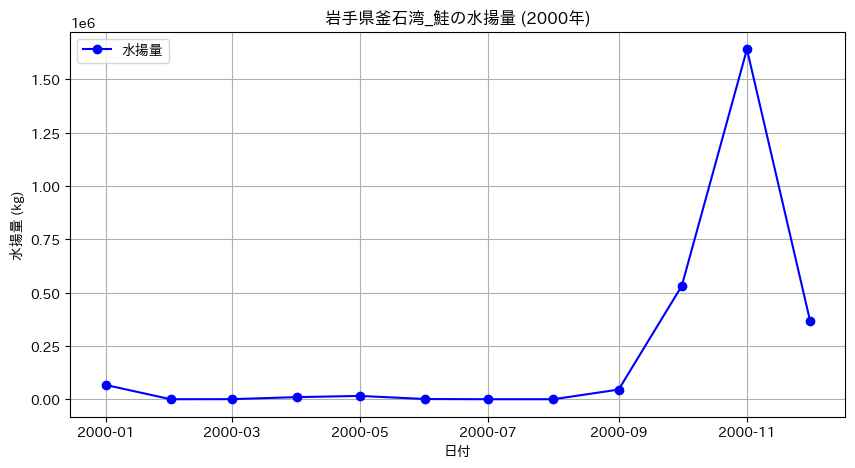

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# データパス
data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量(鮭)_結合データ.csv"

# 読み込み
df = pd.read_csv(data_file)

# 日付をdatetime形式に変換
df["日付"] = pd.to_datetime(df["日付"], format="%Y/%m")

# 特定の範囲に絞り込む
year = "2000"
start_date = f"{year}-01-01"
end_date = f"{year}-12-01"
filtered_df = df[(df["日付"] >= start_date) & (df["日付"] <= end_date)]

# グラフの作成
plt.figure(figsize=(10, 5))
plt.plot(filtered_df["日付"], filtered_df["水揚量(kg)"], marker="o", linestyle="-", color="b", label="水揚量")
plt.xlabel("日付")
plt.ylabel("水揚量 (kg)")
plt.title(f"岩手県釜石湾_鮭の水揚量 ({year}年)")
plt.grid(True)
plt.legend()
plt.show()

In [38]:
%%bash

cd /content/drive/MyDrive/研究用/AI-research
